# mmFall Fall Detection — Representation 2: Orthogonal Projections (ResNet-18)

This notebook processes the **Representation 2 (Dual Orthogonal 2D Spatial Projections)** format for mmWave radar fall detection, training a **ResNet-18** spatial model in PyTorch as specified in the research plan (*'Comparing mmWave Radar Data Formats for Fall Detection' by Joey van der Poel*).

---

### Representation & Model Specifications:
- **Representation Format**: Dual 2D Spatial Grid Image $I \in \mathbb{R}^{3 \times 64 \times 64}$.
- **Channels**: 3 Channels ($XZ$ Side Elevation Grid, $XY$ Ground Plan Grid, and Velocity-Weighted Projection Grid).
- **Target Posture**: Captures vertical height drop ($Z$-axis elevation) and horizontal body area expansion during collapse.
- **Model Backbone**: PyTorch **ResNet-18** Spatial Feature Extractor.


In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

# Load Preprocessed Representation 2 Tensors
preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../../datasets/preprocessed")
X_rep2 = np.load(preproc_dir / "X_rep2_projections.npy") # Shape: (1182, 3, 64, 64)
y_rep2 = np.load(preproc_dir / "y_rep2_projections.npy") # Shape: (1182,)

print(f"Loaded Representation 2 Projections Tensor: {X_rep2.shape}")
print(f"Labels: {np.bincount(y_rep2.astype(int))} (0 = ADL, 1 = Fall)")


Loaded Representation 2 Projections Tensor: (1182, 3, 64, 64)
Labels: [591 591] (0 = ADL, 1 = Fall)


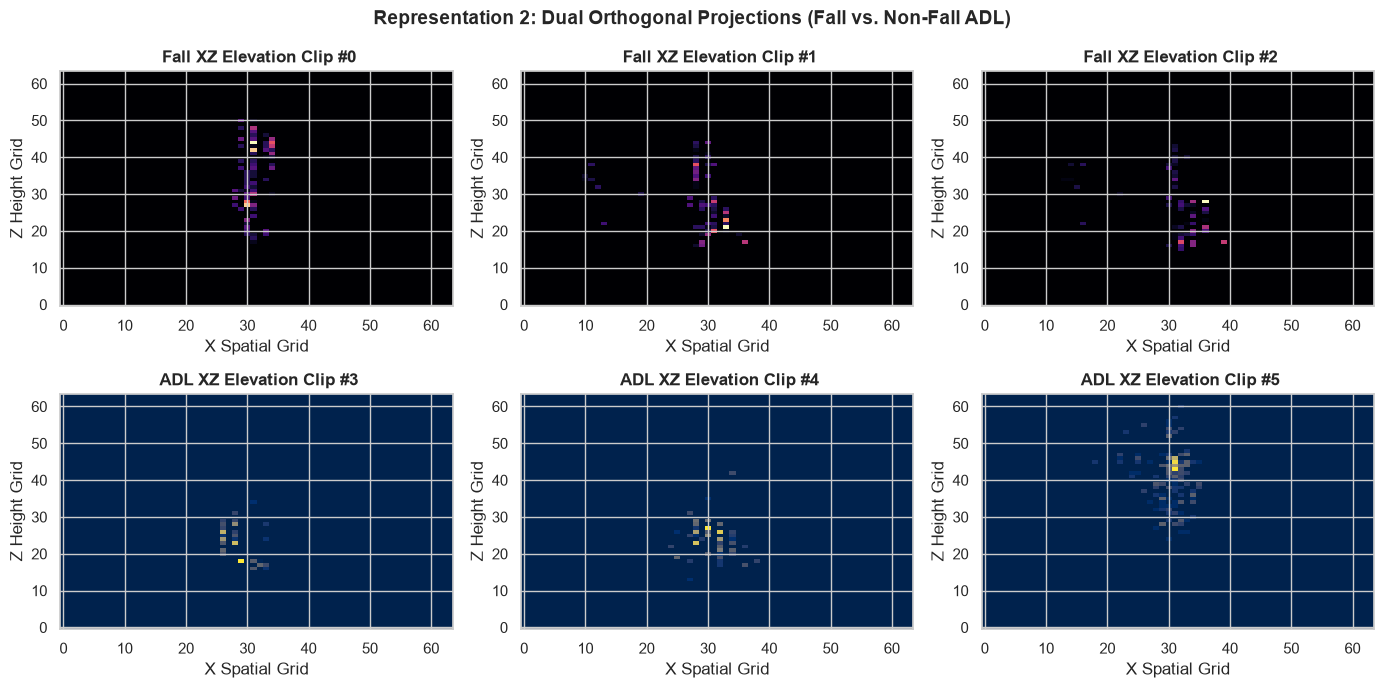

In [2]:
# Visualize Sample Orthogonal Spatial Projections
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fall_indices = np.where(y_rep2 == 1)[0]
adl_indices = np.where(y_rep2 == 0)[0]

for i in range(3):
    idx_f = fall_indices[i]
    idx_a = adl_indices[i]
    axes[0, i].imshow(X_rep2[idx_f, 0], aspect="auto", cmap="magma", origin="lower")
    axes[0, i].set_title(f" Fall XZ Elevation Clip #{idx_f}", fontweight="bold")
    axes[0, i].set_xlabel("X Spatial Grid")
    axes[0, i].set_ylabel("Z Height Grid")
    
    axes[1, i].imshow(X_rep2[idx_a, 0], aspect="auto", cmap="cividis", origin="lower")
    axes[1, i].set_title(f" ADL XZ Elevation Clip #{idx_a}", fontweight="bold")
    axes[1, i].set_xlabel("X Spatial Grid")
    axes[1, i].set_ylabel("Z Height Grid")

plt.suptitle("Representation 2: Dual Orthogonal Projections (Fall vs. Non-Fall ADL)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [3]:
# Define ResNet-18 Spatial Model in PyTorch
class ResNet18Projections(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(ResNet18Projections, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        feat = torch.flatten(self.features(x), 1)
        return self.fc(feat)

# Split Train & Test Sets (80% / 20% Stratified)
X_tr, X_te, y_tr, y_te = train_test_split(X_rep2, y_rep2, test_size=0.2, random_state=42, stratify=y_rep2)
print(f"Train samples: {len(X_tr)}, Test samples: {len(X_te)}")


Train samples: 945, Test samples: 237


In [4]:
# Train ResNet18Projections Model with Best Model Checkpointing
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18Projections().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
te_ds = TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.long))
tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
te_loader = DataLoader(te_ds, batch_size=32, shuffle=False)

# Best Model Checkpoint Path
models_dir = Path("models")
if not models_dir.exists(): models_dir = Path("../models")
if not models_dir.exists(): models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / "resnet18_rep2_projections_mmfall.pth"

epochs = 15
losses, accs = [], []
best_val_loss = float('inf')

for ep in range(epochs):
    model.train()
    r_loss, corr, tot = 0.0, 0, 0
    for bx, by in tr_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        r_loss += loss.item() * bx.size(0)
        preds = out.argmax(dim=1)
        corr += (preds == by).sum().item()
        tot += by.size(0)
    train_loss = r_loss / tot
    train_acc = corr / tot
    losses.append(train_loss)
    accs.append(train_acc)

   # Validation step to track best model
    model.eval()
    val_loss, val_corr, val_tot = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in te_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            v_loss = criterion(out, by)
            val_loss += v_loss.item() * bx.size(0)
            val_corr += (out.argmax(dim=1) == by).sum().item()
            val_tot += by.size(0)
    val_loss /= val_tot
    val_acc = val_corr / val_tot
    scheduler.step(val_loss)

   # Checkpoint best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        saved_flag = " [BEST SAVED]"
    else:
        saved_flag = ""

    print(f"Epoch [{ep+1:02d}/{epochs:02d}] Tr Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%{saved_flag}")

# Reload best model weights for evaluation
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"\nLoaded best model checkpoint from: {best_model_path} (Best Val Loss: {best_val_loss:.4f})")

Epoch [01/15] Tr Loss: 0.6550, Acc: 62.96% | Val Loss: 0.7135, Acc: 49.79% [BEST SAVED]


Epoch [02/15] Tr Loss: 0.5586, Acc: 71.85% | Val Loss: 0.6297, Acc: 67.09% [BEST SAVED]


Epoch [03/15] Tr Loss: 0.5465, Acc: 72.70% | Val Loss: 0.6945, Acc: 59.92%


Epoch [04/15] Tr Loss: 0.5339, Acc: 74.07% | Val Loss: 0.7012, Acc: 66.24%


Epoch [05/15] Tr Loss: 0.4977, Acc: 77.04% | Val Loss: 2.0282, Acc: 50.21%


...

Epoch [11/15] Tr Loss: 0.3107, Acc: 86.46% | Val Loss: 4.0398, Acc: 50.21%


Epoch [12/15] Tr Loss: 0.2547, Acc: 89.74% | Val Loss: 0.9304, Acc: 65.82%


Epoch [13/15] Tr Loss: 0.2540, Acc: 89.74% | Val Loss: 1.0269, Acc: 59.92%


Epoch [14/15] Tr Loss: 0.1968, Acc: 92.80% | Val Loss: 1.3328, Acc: 59.49%


Epoch [15/15] Tr Loss: 0.1562, Acc: 94.50% | Val Loss: 0.8088, Acc: 70.04%

Loaded best model checkpoint from: ..\..\models\resnet18_rep2_projections_mmfall.pth (Best Val Loss: 0.5928)


--- Representation 2 (Projections ResNet-18) Test Results ---
Test Accuracy: 69.20%
ROC-AUC Score: 0.7636

Classification Report:
                  precision    recall  f1-score   support

 ADL (Non-Fall)       0.69      0.69      0.69       119
           Fall       0.69      0.69      0.69       118

       accuracy                           0.69       237
      macro avg       0.69      0.69      0.69       237
   weighted avg       0.69      0.69      0.69       237



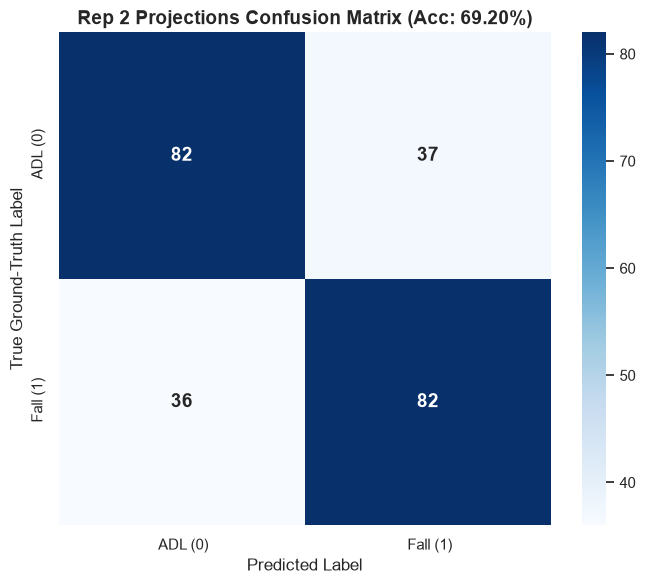

Saved Representation_2_Orthogonal_Projections benchmark metrics to ..\..\models\representation_benchmark_results.json


In [5]:
# Evaluate on Test Set
model.eval()
preds_list, probs_list, targets_list = [], [], []
with torch.no_grad():
    for bx, by in te_loader:
        bx = bx.to(device)
        out = model(bx)
        prob = torch.softmax(out, dim=1)[:, 1]
        preds_list.extend(out.argmax(dim=1).cpu().numpy())
        probs_list.extend(prob.cpu().numpy())
        targets_list.extend(by.numpy())

targets_arr = np.array(targets_list)
preds_arr = np.array(preds_list)
probs_arr = np.array(probs_list)

acc = accuracy_score(targets_arr, preds_arr)
auc = roc_auc_score(targets_arr, probs_arr)
cm = confusion_matrix(targets_arr, preds_arr)

print(f"--- Representation 2 (Projections ResNet-18) Test Results ---")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"ROC-AUC Score: {auc:.4f}")
print("\nClassification Report:\n", classification_report(targets_arr, preds_arr, target_names=[" ADL (Non-Fall)", " Fall"]))

# Visual Confusion Matrix Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[" ADL (0)", " Fall (1)"],
            yticklabels=[" ADL (0)", " Fall (1)"],
            annot_kws={"size": 14, "weight": "bold"})
plt.title(f"Rep 2 Projections Confusion Matrix (Acc: {acc*100:.2f}%)", fontweight="bold", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Ground-Truth Label", fontsize=12)
plt.tight_layout()
plt.show()




# Save benchmark metrics to JSON for comparative analysis
import json
from sklearn.metrics import recall_score, precision_score, f1_score
rec = float(recall_score(targets_arr, preds_arr))
prec = float(precision_score(targets_arr, preds_arr))
f1 = float(f1_score(targets_arr, preds_arr))
fpr = float(cm[0, 1] / (cm[0, 0] + cm[0, 1])) if (cm[0, 0] + cm[0, 1]) > 0 else 0.0

models_dir = Path("models")
if not models_dir.exists(): models_dir = Path("../models")
if not models_dir.exists(): models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)
results_path = models_dir / "representation_benchmark_results_mmfall.json"
default_path = models_dir / "representation_benchmark_results.json"

bm_res = {}
if results_path.exists():
    try:
        with open(results_path, "r") as f:
            bm_res = json.load(f)
    except Exception:
        bm_res = {}

bm_res["Representation_2_Orthogonal_Projections"] = {
    "accuracy": float(acc),
    "recall": rec,
    "precision": prec,
    "f1_score": f1,
    "roc_auc": float(auc),
    "fpr": fpr,
    "confusion_matrix": cm.tolist(),
    "test_targets": targets_arr.tolist(),
    "test_probs": probs_arr.tolist()
}

with open(results_path, "w") as f:
    json.dump(bm_res, f, indent=4)
if dataset_tag == "mmfall":
    with open(default_path, "w") as f:
        json.dump(bm_res, f, indent=4)
print(f"Saved Representation_2_Orthogonal_Projections benchmark metrics to {results_path}")
